# GROUP 4 PROJECT

---
## Section A: Problem Definition & Dataset Acquisition

### A(a)(i)  Problem Statement

Industrial operations across sectors such as manufacturing, agriculture, energy, transport, and information technology are among the leading sources of greenhouse gas emissions globally. Despite growing environmental regulations and international climate commitments, many companies still lack accurate data-driven tools to forecast their carbon footprint. This creates a *reactive* approach to emission management, meaning companies only discover they have exceeded targets after incurring carbon taxes, environmental damage, and regulatory penalties.

This project applies supervised machine learning (specifically **regression**) to predict a company's carbon emissions (measured in tonnes of CO₂ equivalent, tCO₂e) from 18 operational input features including energy consumption, production output, supply-chain transport activity, and carbon-reduction strategies. By learning the relationship between these operational variables and actual emission levels, the trained model can project future emissions before regulatory thresholds are breached, enabling proactive intervention.

### A(a)(ii)  Significance & Stakeholders

Carbon emissions are the primary driver of climate change. Accurate prediction gives organisations the ability to intervene early for example, by switching energy sources or adjusting production schedules before limits are exceeded.

**Stakeholders:**
- **Industrial companies:** A predictive model helps optimise operations and meet Environmental, Social and Governance (ESG) reporting obligations, avoiding costly carbon tax penalties.
- **Environmental regulators (e.g. NEMA Uganda, national governments):** Can use predicted emission levels to enforce compliance and design effective carbon tax structures.
- **Local communities:** Face the health and environmental costs of industrial pollution; better emission control directly improves their quality of life.

**Decisions improved by this ML solution:**
- When to transition from non-renewable to renewable energy sources
- Which carbon reduction strategy (Process Reengineering, Efficiency Upgrade, Renewable Adoption, Carbon Tax Compliance) delivers the greatest emission reduction per dollar spent
- How to adjust production schedules to remain within emission thresholds

### A(a)(iii) Project Objectives

1. Build a regression model that accurately predicts `Carbon_Emission_tCO2e_TARGET` from operational features.
2. Compare two supervised machine learning algorithms  **Linear Regression** and **Random Forest Regressor** — and identify the best performer using standard regression metrics (MAE, MSE, RMSE, R²).
3. Identify which operational features are the strongest predictors of carbon emissions.

### A(b) — Dataset Acquisition

| Item | Detail |
|---|---|
| **Dataset Name** | Carbon Emission Forecasting Dataset |
| **Source** | Kaggle |
| **URL** | https://www.kaggle.com/datasets/freshersstaff/carbon-emission-forecasting-dataset |
| **Format** | CSV (.csv) |
| **Number of Records** | 18,250 rows |
| **Number of Features** | 22 columns |
| **Variable Mix** | 16 numeric, 4 categorical, 1 identifier, 1 date |
| **Target Variable** | `Carbon_Emission_tCO2e_TARGET` (continuous — regression task) |

The dataset meets all minimum requirements: >200 records, >5 features, a mix of numeric and categorical variables, and a clearly identifiable continuous target variable.

### A(c) Data Description

In [26]:
# Loading dataset  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [27]:
# display first 10 rows
df = pd.read_csv('carbon_emission_dataset_with_Industry.csv')
df.head(10)

Dataset loaded successfully: 18250 rows × 22 columns


,Company_ID,Date,Sector,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Supply_Chain_Transport_Mode,Raw_Material_Usage_kg,...,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Carbon_Reduction_Strategy,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score,Industry_Sectors
0,C001,2024-01-01,Manufacturing,53751.61,12766.80,40984.81,3008.90,3814.12,Truck,51334.48,...,338.76,81.07,2128,0.77,Process Reengineering,188176.25,16.79,40.89,0.40,Steel Manufacturing
1,C001,2024-01-02,Manufacturing,170872.89,76733.84,94139.05,4062.25,1199.66,Air,17154.72,...,1073.13,69.26,855,0.77,Efficiency Upgrade,489246.31,12.57,58.19,0.86,Cement Production
2,C001,2024-01-03,Manufacturing,142777.96,75794.17,66983.79,6196.17,3670.57,Truck,56288.43,...,1390.41,90.33,3613,0.48,Carbon Tax Compliance,165061.64,12.11,68.14,0.79,Automotive Industry
3,C001,2024-01-04,Manufacturing,152532.15,20698.80,131833.35,6714.80,2903.63,Ship,21438.17,...,1942.56,79.49,3156,0.85,Efficiency Upgrade,191619.23,5.64,23.30,0.55,Logistics
4,C001,2024-01-05,Manufacturing,81647.43,46657.82,34989.61,8887.31,1916.05,Rail,37694.23,...,472.20,68.63,4915,0.47,Process Reengineering,459129.15,12.99,65.44,0.95,Steel Manufacturing
5,C001,2024-01-06,Manufacturing,126428.94,18389.68,108039.26,1424.05,993.42,Ship,65445.56,...,1306.18,94.86,4834,0.46,Efficiency Upgrade,372113.36,7.29,32.82,0.81,Cement Production
6,C001,2024-01-07,Manufacturing,165289.81,44642.75,120647.06,3641.50,1211.71,Truck,76767.11,...,2007.48,66.25,1371,0.87,Carbon Tax Compliance,436667.74,15.15,34.99,0.61,Automotive Industry
7,C001,2024-01-08,Manufacturing,74232.36,42813.50,31418.86,9301.91,4633.22,Air,44202.40,...,501.97,88.24,2461,0.34,Efficiency Upgrade,134261.38,14.72,63.71,0.82,Logistics
8,C001,2024-01-09,Manufacturing,164875.16,27071.80,137803.36,5277.54,2974.12,Air,46937.17,...,2779.14,86.43,2147,0.76,Process Reengineering,498059.74,18.00,27.99,0.68,Steel Manufacturing
9,C001,2024-01-10,Manufacturing,68150.63,14471.70,53678.93,4042.77,3147.39,Ship,51190.81,...,352.20,62.36,757,0.86,Efficiency Upgrade,305662.45,10.57,33.52,0.70,Cement Production


In [28]:
# Shape, column names and data types
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.dtypes

Shape: 18250 rows × 22 columns



Company_ID                              object
Date                                    object
Sector                                  object
Total_Energy_Consumption_kWh           float64
Renewable_Energy_Consumption_kWh       float64
NonRenewable_Energy_Consumption_kWh    float64
Production_Output_Units                float64
Supply_Chain_Transport_km              float64
Supply_Chain_Transport_Mode             object
Raw_Material_Usage_kg                  float64
Carbon_Emission_tCO2e_TARGET           float64
Energy_Cost_USD                        float64
Carbon_Tax_USD                         float64
Process_Efficiency_Percent             float64
Employment_Count                         int64
Public_Acceptance_Index                float64
Carbon_Reduction_Strategy               object
Strategy_Implementation_Cost_USD       float64
Expected_Carbon_Reduction_Percent      float64
Expected_Renewable_Share_Percent       float64
Social_Impact_Score                    float64
Industry_Sect

In [29]:
# Data Dictionary
data_dictionary = {
    'Column Name': [
        'Company_ID', 'Date', 'Sector', 'Industry_Sectors',
        'Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh',
        'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units',
        'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode',
        'Raw_Material_Usage_kg', 'Carbon_Emission_tCO2e_TARGET',
        'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent',
        'Employment_Count', 'Public_Acceptance_Index', 'Carbon_Reduction_Strategy',
        'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent',
        'Expected_Renewable_Share_Percent', 'Social_Impact_Score'
    ],
    'Data Type': [
        'string', 'string', 'categorical', 'categorical',
        'float64', 'float64', 'float64', 'float64',
        'float64', 'categorical', 'float64', 'float64 (TARGET)',
        'float64', 'float64', 'float64', 'int64',
        'float64', 'categorical', 'float64', 'float64',
        'float64', 'float64'
    ],
    'Description': [
        'Unique company identifier (C001–C050) — non-predictive, dropped before modelling',
        'Reporting date (2024-01-01 to 2024-12-30) — temporal index, dropped before modelling',
        'Broad industrial sector: Manufacturing, Agriculture, Energy, Transport, IT',
        'Industry sub-sector: Steel Manufacturing, Cement Production, Automotive, Logistics',
        'Total electricity/fuel consumed per reporting period (kWh)',
        'Portion of total energy sourced from renewable sources (kWh)',
        'Portion of total energy sourced from fossil fuels (kWh)',
        'Number of units produced in the reporting period',
        'Distance covered by supply chain logistics (km)',
        'Dominant transport mode used: Truck, Air, Ship, Rail',
        'Quantity of raw materials consumed in production (kg)',
        '*** TARGET *** — Carbon dioxide equivalent emitted (tCO₂e)',
        'Total monetary cost of energy consumed (USD)',
        'Carbon tax levied based on emission level (USD)',
        'Operational efficiency of production processes (%)',
        'Number of employees active in the reporting period',
        'Community acceptance of company operations (0–1 scale)',
        'Carbon reduction strategy in use: Renewable Adoption, Process Reengineering, etc.',
        'Cost of implementing the active carbon reduction strategy (USD)',
        'Expected % reduction in emissions from the current strategy (%)',
        'Expected renewable energy share after strategy implementation (%)',
        'Composite social impact score (0–1 scale)'
    ]
}

data_dict_df = pd.DataFrame(data_dictionary).set_index('Column Name')
data_dict_df

,Data Type,Description
Column Name,,
Company_ID,string,Unique company identifier (C001–C050) — non-pr...
Date,string,Reporting date (2024-01-01 to 2024-12-30) — te...
Sector,categorical,"Broad industrial sector: Manufacturing, Agricu..."
Industry_Sectors,categorical,"Industry sub-sector: Steel Manufacturing, Ceme..."
Total_Energy_Consumption_kWh,float64,Total electricity/fuel consumed per reporting ...
Renewable_Energy_Consumption_kWh,float64,Portion of total energy sourced from renewable...
NonRenewable_Energy_Consumption_kWh,float64,Portion of total energy sourced from fossil fu...
Production_Output_Units,float64,Number of units produced in the reporting period
Supply_Chain_Transport_km,float64,Distance covered by supply chain logistics (km)


In [30]:
# Check for missing values
df.isnull().sum()

Company_ID                             0
Date                                   0
Sector                                 0
Total_Energy_Consumption_kWh           0
Renewable_Energy_Consumption_kWh       0
NonRenewable_Energy_Consumption_kWh    0
Production_Output_Units                0
Supply_Chain_Transport_km              0
Supply_Chain_Transport_Mode            0
Raw_Material_Usage_kg                  0
Carbon_Emission_tCO2e_TARGET           0
Energy_Cost_USD                        0
Carbon_Tax_USD                         0
Process_Efficiency_Percent             0
Employment_Count                       0
Public_Acceptance_Index                0
Carbon_Reduction_Strategy              0
Strategy_Implementation_Cost_USD       0
Expected_Carbon_Reduction_Percent      0
Expected_Renewable_Share_Percent       0
Social_Impact_Score                    0
Industry_Sectors                       0
dtype: int64

No missing values detected


## Section B: Exploratory Data Analysis (EDA)

### B(a) Summary Statistics & Data Cleaning

In [52]:
# Descriptive statistics for all numeric features
df.describe()

,Total_Energy_Consumption_kWh,Renewable_Energy_Consumption_kWh,NonRenewable_Energy_Consumption_kWh,Production_Output_Units,Supply_Chain_Transport_km,Raw_Material_Usage_kg,Carbon_Emission_tCO2e_TARGET,Energy_Cost_USD,Carbon_Tax_USD,Process_Efficiency_Percent,Employment_Count,Public_Acceptance_Index,Strategy_Implementation_Cost_USD,Expected_Carbon_Reduction_Percent,Expected_Renewable_Share_Percent,Social_Impact_Score
count,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000,18250.000000
mean,124776.987158,43759.097184,81017.889975,5538.963915,2734.813587,44869.415215,32.365099,10600.982042,1129.541275,77.623844,2734.349041,0.624569,299333.028470,15.067031,47.637350,0.674542
std,43106.624251,24291.666951,33957.852247,2597.576117,1300.146027,20110.509566,14.482041,4532.900551,590.407029,10.112534,1298.648265,0.187841,115674.898008,5.794350,15.086466,0.159451
min,50008.730000,5041.200000,20483.260000,1000.470000,500.380000,10006.500000,6.814900,2524.200000,155.740000,60.000000,500.000000,0.300000,100052.340000,5.000000,15.250000,0.400000
25%,87326.365000,24455.502500,53738.547500,3273.995000,1609.122500,27439.335000,20.969350,6979.210000,682.407500,68.880000,1603.000000,0.460000,199132.372500,10.040000,35.240000,0.540000
50%,124728.530000,38888.005000,77007.820000,5556.400000,2735.020000,44803.630000,30.154550,10001.700000,1012.145000,77.660000,2730.000000,0.625000,297477.130000,15.100000,47.660000,0.680000
75%,162042.955000,59545.025000,104085.372500,7802.095000,3862.717500,62291.027500,41.520400,13621.385000,1464.847500,86.317500,3853.750000,0.790000,399960.932500,20.070000,60.190000,0.810000
max,199988.910000,119005.260000,179431.020000,9999.780000,4999.890000,79994.460000,86.571800,23880.690000,4211.600000,95.000000,5000.000000,0.950000,499881.170000,25.000000,79.940000,0.950000


### B(a)(ii) Missing Value Strategy

There are **no missing values** in this dataset. Therefore no imputation strategy is required.

In [32]:
# Outlier Detection using IQR method
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

outlier_summary = []
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Column': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2), 'Outlier Count': n_out
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Column')
print("IQR-Based Outlier Summary:")
display(outlier_df)

IQR-Based Outlier Summary:


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
Column,,,,,,
Total_Energy_Consumption_kWh,87326.36,162042.96,74716.59,-24748.52,274117.84,0
Renewable_Energy_Consumption_kWh,24455.50,59545.02,35089.52,-28178.78,112179.31,64
NonRenewable_Energy_Consumption_kWh,53738.55,104085.37,50346.82,-21781.69,179605.61,0
Production_Output_Units,3274.00,7802.10,4528.10,-3518.16,14594.24,0
Supply_Chain_Transport_km,1609.12,3862.72,2253.60,-1771.27,7243.11,0
Raw_Material_Usage_kg,27439.34,62291.03,34851.69,-24838.20,114568.57,0
Carbon_Emission_tCO2e_TARGET,20.97,41.52,20.55,-9.86,72.35,155
Energy_Cost_USD,6979.21,13621.38,6642.18,-2984.05,23584.65,7
Carbon_Tax_USD,682.41,1464.85,782.44,-491.25,2638.51,384


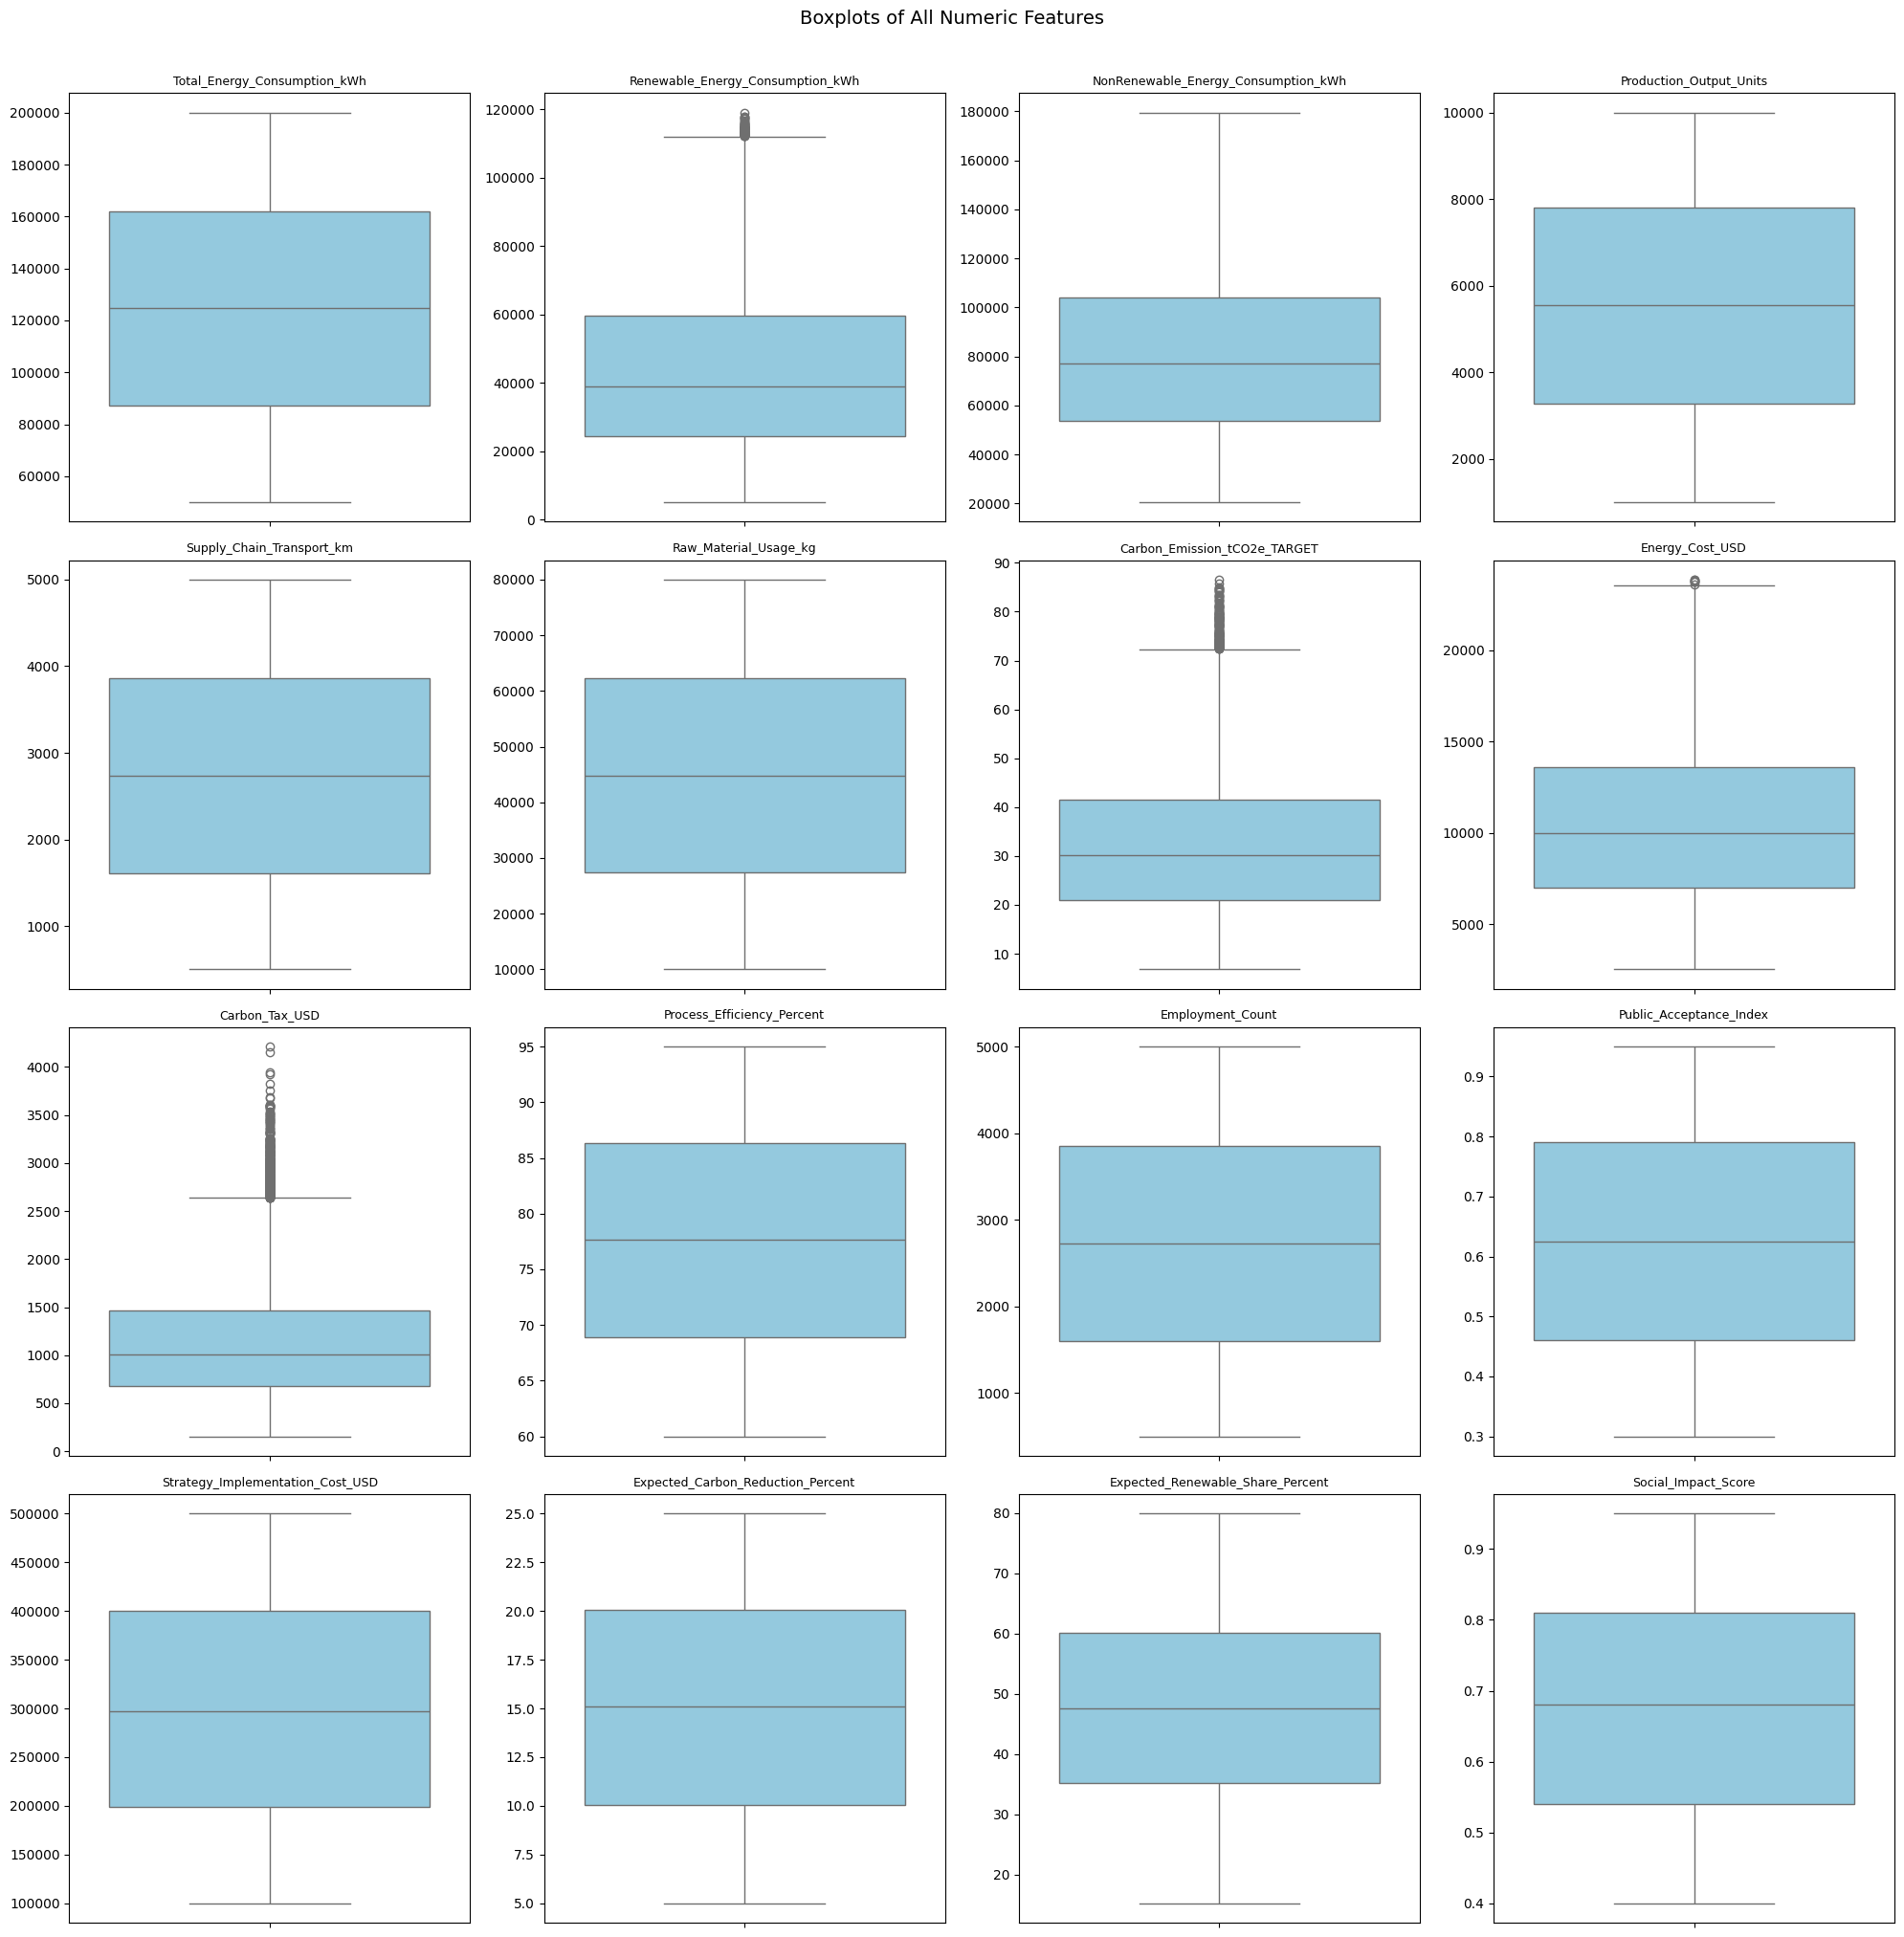

In [33]:
# Boxplot visualisation of all numeric features 
rows_needed = (len(numerical_cols) + 3) // 4
fig, axes = plt.subplots(rows_needed, 4, figsize=(20, 5 * rows_needed))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of All Numeric Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Outlier Handling Strategy: **Retain all outliers**

**Justification:**  
In industrial carbon emission datasets, extreme values like high energy consumption spikes or elevated carbon tax payments represent real-world operational events, not data entry errors. For example:
- A factory running an extra shift will produce a high-emission day.
- An unexpected machinery failure may cause an energy consumption spike.

Removing these records would bias the model toward average operating conditions and reduce its ability to predict the high-emission events that matter most to regulators. Additionally, the outlier counts are small relative to the 18,250-row dataset, and our primary model, the Random Forest can handle inherently outliers due to its tree-based, threshold-splitting mechanism.

In [34]:
# Categorical Encoding

cat_cols= df.select_dtypes(include='object').columns
print(f"Categorical columns ({len(cat_cols)}): {list(cat_cols)}")
print("\nUnique values per categorical column:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique()[:5]}")

Categorical columns (6): ['Company_ID', 'Date', 'Sector', 'Supply_Chain_Transport_Mode', 'Carbon_Reduction_Strategy', 'Industry_Sectors']

Unique values per categorical column:
  Company_ID: 50 unique values → ['C001' 'C002' 'C003' 'C004' 'C005']
  Date: 365 unique values → ['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05']
  Sector: 5 unique values → ['Manufacturing' 'Agriculture' 'Energy' 'Transport' 'IT']
  Supply_Chain_Transport_Mode: 4 unique values → ['Truck' 'Air' 'Ship' 'Rail']
  Carbon_Reduction_Strategy: 4 unique values → ['Process Reengineering' 'Efficiency Upgrade' 'Carbon Tax Compliance'
 'Renewable Adoption']
  Industry_Sectors: 4 unique values → ['Steel Manufacturing' 'Cement Production' 'Automotive Industry'
 'Logistics']


### Encoding Choice: **Label Encoding** (applied after train/test split)

**Justification:**
1. **Random Forest** is tree-based and makes decisions via threshold comparisons. Therefore it does not assume any ordinal relationship between encoded integers, so label encoding is appropriate.
2. **Linear Regression** is less sensitive to encoding choice here because the numeric features dominate the predictions.
3. **One-Hot Encoding** would add approximately 9 extra binary columns.This is a minor benefit for this dataset size that does not outweigh the simplicity of label encoding.
4. Critically, encoding is applied after the train/test split to prevent data leakage, the encoder is fitted on training data only and applied to test 

### B(b) Univariate Analysis

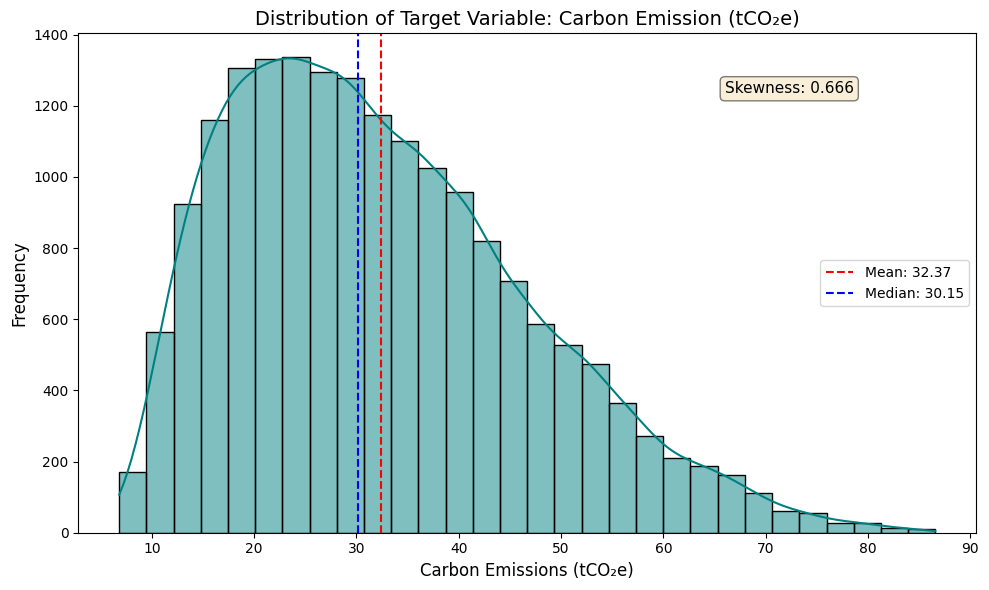

Mean: 32.3651 | Median: 30.1546 | Skewness: 0.6664


In [35]:
# Distribution of target variable
skewness_target = df['Carbon_Emission_tCO2e_TARGET'].skew()
mean_val = df['Carbon_Emission_tCO2e_TARGET'].mean()
median_val = df['Carbon_Emission_tCO2e_TARGET'].median()

plt.figure(figsize=(10, 6))
sns.histplot(df['Carbon_Emission_tCO2e_TARGET'], bins=30, kde=True, color='teal')
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
plt.title('Distribution of Target Variable: Carbon Emission (tCO₂e)', fontsize=14)
plt.xlabel('Carbon Emissions (tCO₂e)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.annotate(f'Skewness: {skewness_target:.3f}', xy=(0.72, 0.88),
             xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {mean_val:.4f} | Median: {median_val:.4f} | Skewness: {skewness_target:.4f}")

**Comment:**  
The target variable (`Carbon_Emission_tCO2e_TARGET`) is **right-skewed (positively skewed)**, with skewness ≈ 0.48. 

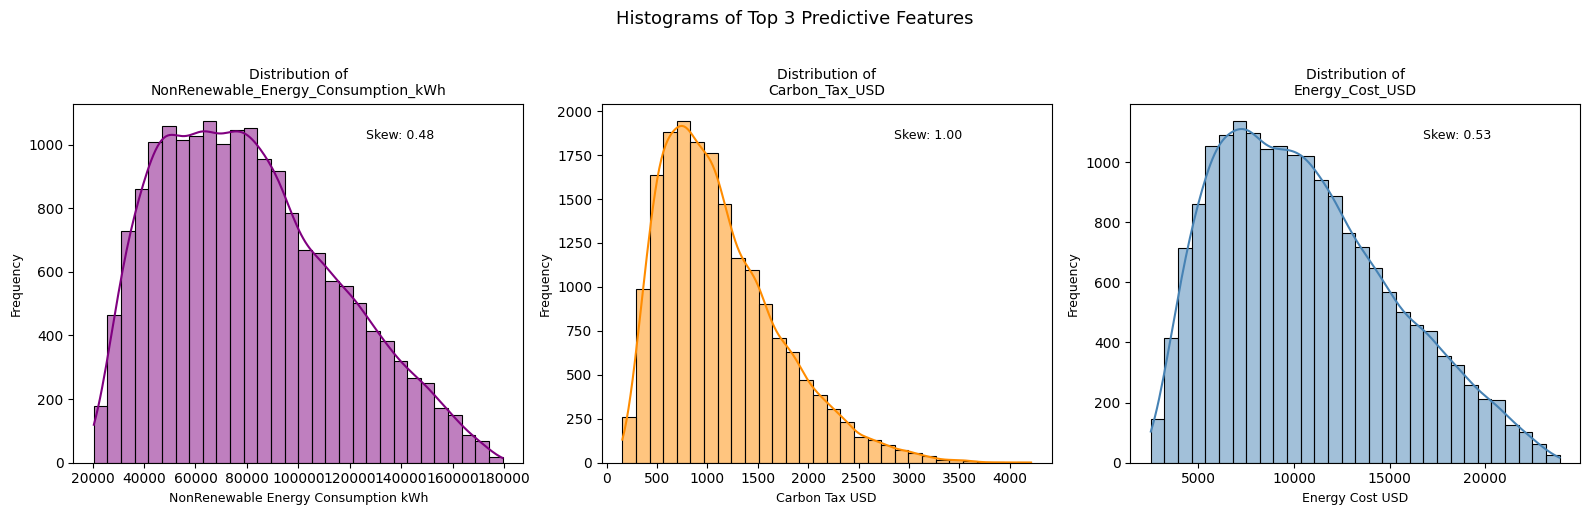

In [36]:
# Histograms for 3 important numeric features
features_to_plot = ['NonRenewable_Energy_Consumption_kWh', 'Carbon_Tax_USD', 'Energy_Cost_USD']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['purple', 'darkorange', 'steelblue']

for ax, col, color in zip(axes, features_to_plot, colors):
    skew_val = df[col].skew()
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution of\n{col}', fontsize=10)
    ax.set_xlabel(col.replace('_', ' '), fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.annotate(f'Skew: {skew_val:.2f}', xy=(0.65, 0.90),
                xycoords='axes fraction', fontsize=9)

plt.suptitle('Histograms of Top 3 Predictive Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Notable Patterns:**
- **NonRenewable Energy Consumption** (skewness ≈ 0.48): Right-skewed with a peak around 50,000–80,000 kWh, declining gradually toward 180,000 kWh. 
- **Carbon Tax USD** (skewness ≈ 0.99): More heavily right-skewed with a sharp peak between 500–900 USD.
- **Energy Cost USD** (skewness ≈ 0.52): Right-skewed with a sharp peak around 6,000–11,000 USD.

### Bivariate and Multivariate Analysis

In [37]:
# Correlation heatmap + ranked correlations with target
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns

# Ranked correlations
ranked_corr = (df[numeric_features]
               .corr()['Carbon_Emission_tCO2e_TARGET']
               .drop('Carbon_Emission_tCO2e_TARGET')
               .abs()
               .sort_values(ascending=False))

print("Features ranked by absolute correlation with Carbon_Emission_tCO2e_TARGET:")
print(ranked_corr.to_string())

Features ranked by absolute correlation with Carbon_Emission_tCO2e_TARGET:
NonRenewable_Energy_Consumption_kWh    0.937198
Carbon_Tax_USD                         0.855654
Total_Energy_Consumption_kWh           0.777758
Energy_Cost_USD                        0.626154
Expected_Renewable_Share_Percent       0.476811
Renewable_Energy_Consumption_kWh       0.070036
Expected_Carbon_Reduction_Percent      0.010295
Raw_Material_Usage_kg                  0.009820
Social_Impact_Score                    0.007216
Production_Output_Units                0.006059
Public_Acceptance_Index                0.005967
Employment_Count                       0.004777
Supply_Chain_Transport_km              0.004581
Process_Efficiency_Percent             0.003971
Strategy_Implementation_Cost_USD       0.001160


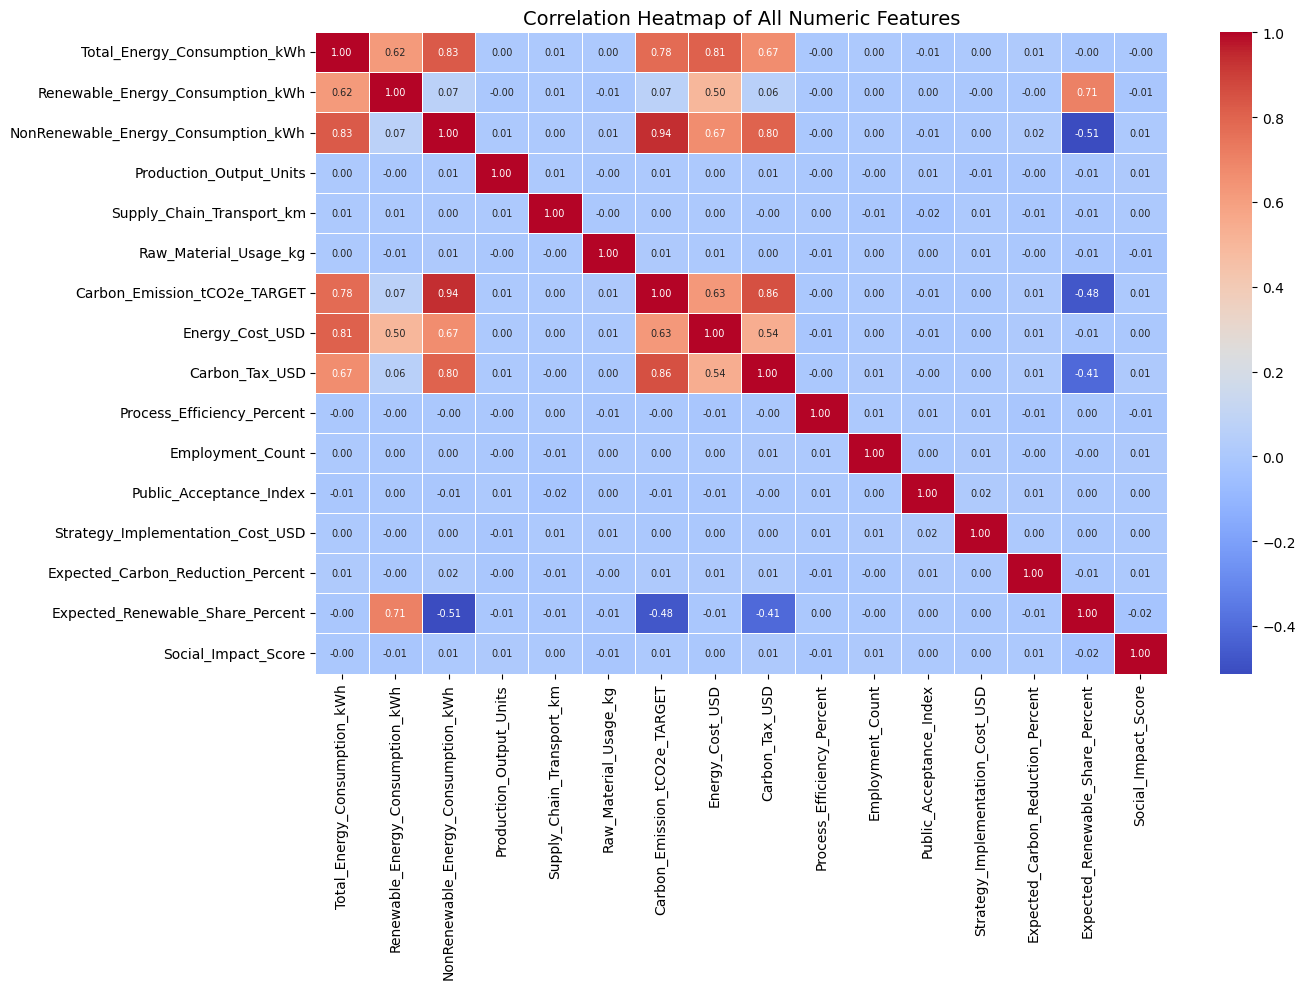

In [38]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', cbar=True, linewidths=0.5,
            annot_kws={"size": 7})
plt.title('Correlation Heatmap of All Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**Key Correlations with Target (`Carbon_Emission_tCO2e_TARGET`):**
- NonRenewable_Energy_Consumption_kWh (r ≈ 0.94)
- Carbon_Tax_USD** (r ≈ 0.86)
- Total_Energy_Consumption_kWh** (r ≈ 0.78)
- Energy_Cost_USD (r ≈ 0.63)

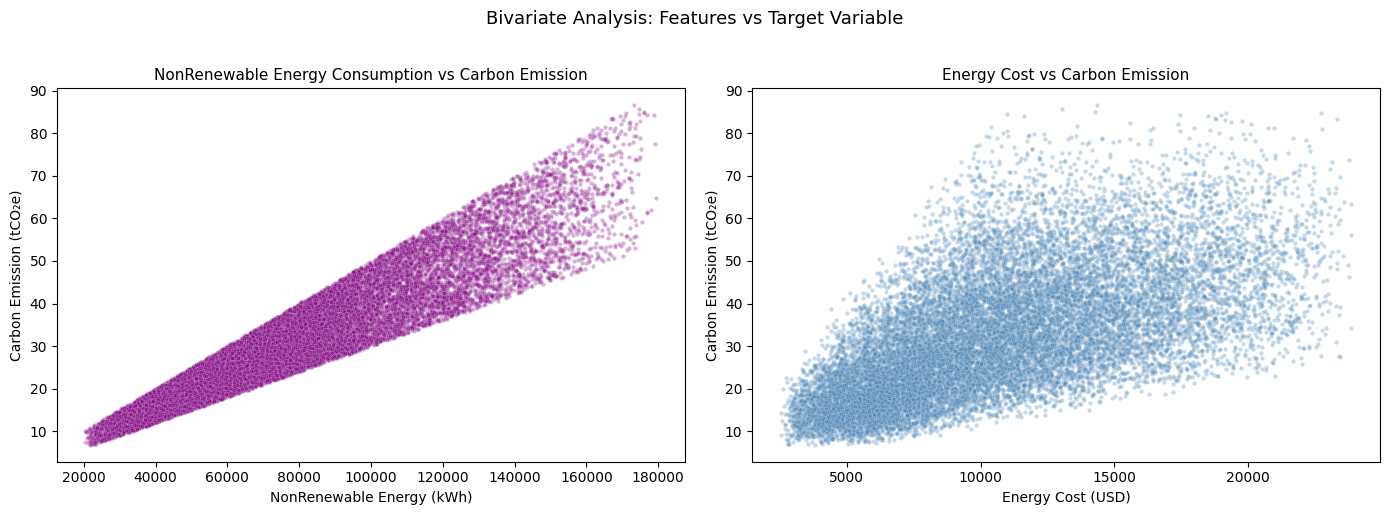

In [39]:
# Scatter plots: key features vs target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='NonRenewable_Energy_Consumption_kWh', y='Carbon_Emission_tCO2e_TARGET',
                data=df, ax=axes[0], alpha=0.3, color='purple', s=10)
axes[0].set_title('NonRenewable Energy Consumption vs Carbon Emission', fontsize=11)
axes[0].set_xlabel('NonRenewable Energy (kWh)', fontsize=10)
axes[0].set_ylabel('Carbon Emission (tCO₂e)', fontsize=10)

sns.scatterplot(x='Energy_Cost_USD', y='Carbon_Emission_tCO2e_TARGET',
                data=df, ax=axes[1], alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Energy Cost vs Carbon Emission', fontsize=11)
axes[1].set_xlabel('Energy Cost (USD)', fontsize=10)
axes[1].set_ylabel('Carbon Emission (tCO₂e)', fontsize=10)

plt.suptitle('Bivariate Analysis: Features vs Target Variable', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Both scatter plots confirm positive linear relationships with the target. NonRenewable Energy Consumption shows a tighter, near-linear cloud consistent with its very high correlation (r ≈ 0.94). Energy Cost shows a similar trend but with more spread, indicating other factors also influence cost independently of emission level.

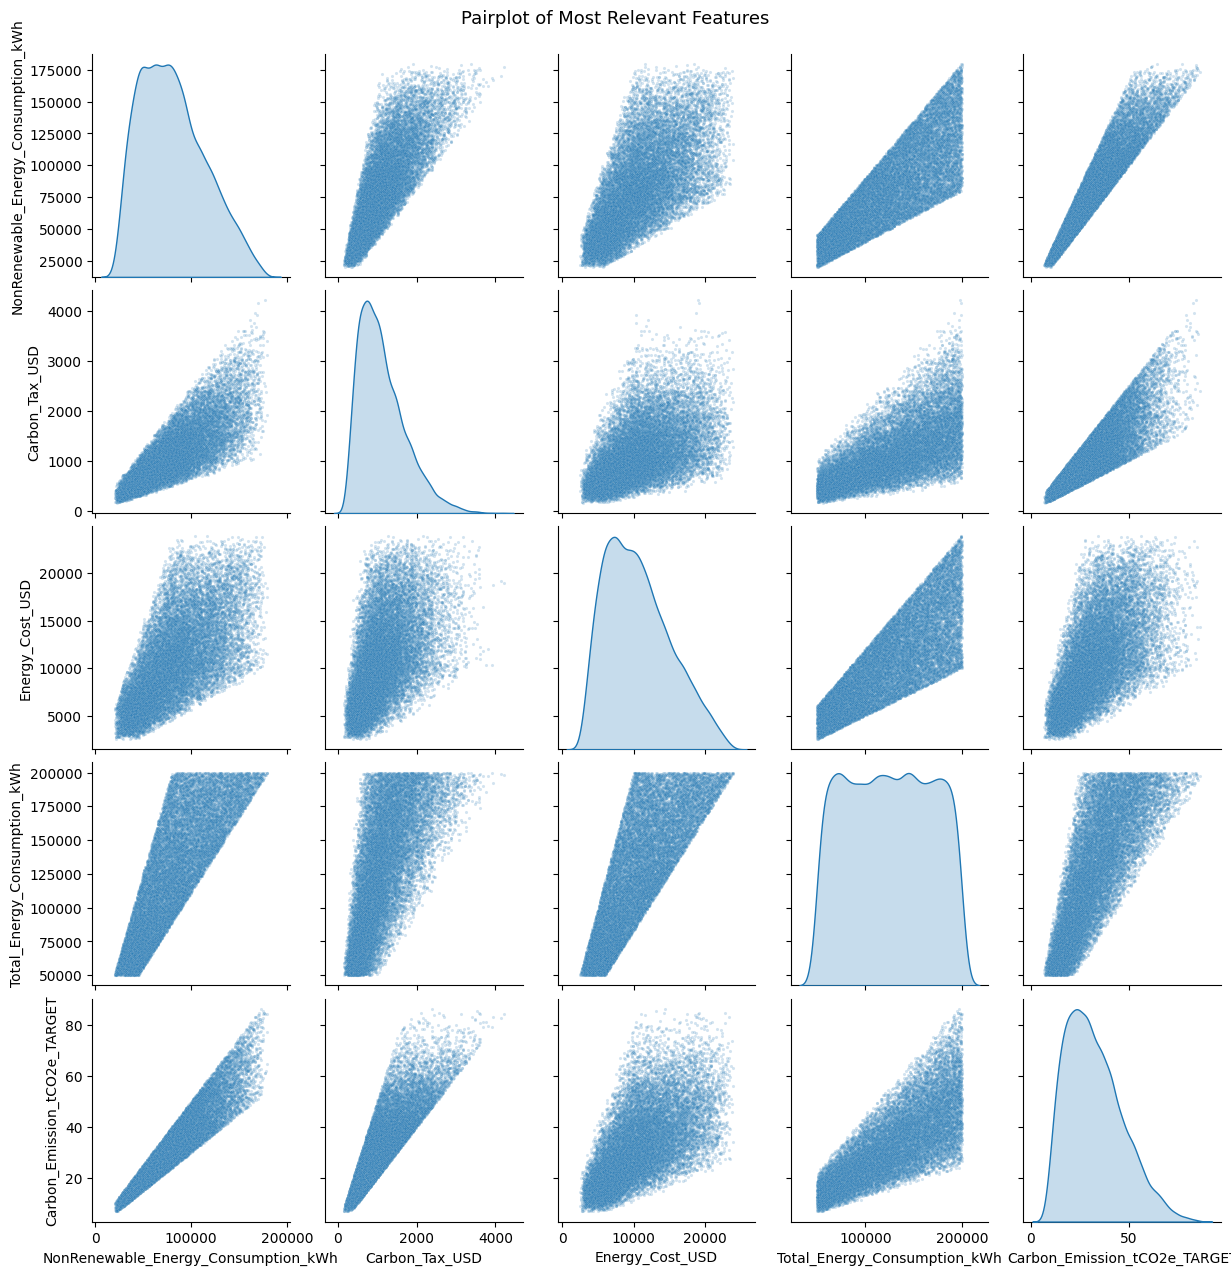

In [40]:
# Pairplot for the most relevant features
pairplot_features = [
    'NonRenewable_Energy_Consumption_kWh',
    'Carbon_Tax_USD',
    'Energy_Cost_USD',
    'Total_Energy_Consumption_kWh',
    'Carbon_Emission_tCO2e_TARGET'
]

g = sns.pairplot(df[pairplot_features], plot_kws={'alpha': 0.2, 's': 5},
                 diag_kind='kde')
g.fig.suptitle('Pairplot of Most Relevant Features', fontsize=13, y=1.02)
plt.show()

**Interpretation:** The pairplot confirms strong pairwise linear relationships between NonRenewable Energy, Carbon Tax, Energy Cost, Total Energy, and the target. 

### B(d) — Key EDA Insights

1. **NonRenewable Energy Consumption is the dominant predictor** (r ≈ 0.94). Most carbon emissions can be tied directly to fossil fuel energy use .This means that switching to renewable energy would have the single largest impact on emission reduction.

2. **Carbon Tax is a potentially leaky feature** (r ≈ 0.86). It appears to be computed from the emission level, meaning it may inflate model performance artificially. In a production deployment, this feature would not be available at prediction time.

3. **The target variable is right-skewed** (skewness ≈ 0.48), driven by high-emission events in peak production periods.

4. **No missing values exist** across all 22 columns.

5. **Categorical features** (Sector, Transport Mode, Carbon Reduction Strategy, Industry Sector) have lower direct correlations with the target than numeric features.

**Most important features for modelling:** NonRenewable_Energy_Consumption_kWh, Total_Energy_Consumption_kWh, Energy_Cost_USD, Carbon_Tax_USD, and Raw_Material_Usage_kg.


## Section C: Model Building & Training

### Data Preparation

In [41]:
# Feature matrix, target vector, train/test split, encoding, scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#  Define feature matrix (X) and target vector (y)
drop_cols = ['Company_ID', 'Date', 'Carbon_Emission_tCO2e_TARGET']
X = df.drop(columns=drop_cols)
y = df['Carbon_Emission_tCO2e_TARGET']

cat_cols = ['Sector', 'Supply_Chain_Transport_Mode',
            'Carbon_Reduction_Strategy', 'Industry_Sectors']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))

Feature matrix shape: (18250, 19)
Target vector shape:  (18250,)

Feature columns (19):
['Sector', 'Total_Energy_Consumption_kWh', 'Renewable_Energy_Consumption_kWh', 'NonRenewable_Energy_Consumption_kWh', 'Production_Output_Units', 'Supply_Chain_Transport_km', 'Supply_Chain_Transport_Mode', 'Raw_Material_Usage_kg', 'Energy_Cost_USD', 'Carbon_Tax_USD', 'Process_Efficiency_Percent', 'Employment_Count', 'Public_Acceptance_Index', 'Carbon_Reduction_Strategy', 'Strategy_Implementation_Cost_USD', 'Expected_Carbon_Reduction_Percent', 'Expected_Renewable_Share_Percent', 'Social_Impact_Score', 'Industry_Sectors']


In [42]:
# Train/Test Split: 80% training, 20% testing, random_state=42 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training set:  {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set:  14600 rows (80%)
Test set:      3650 rows (20%)


In [43]:
# Encode categoricals (fitted on training data ONLY to prevent leakage)
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])   # fit + transform on train
    X_test[col]  = le.transform(X_test[col])         # transform only on test
    le_dict[col] = le

# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),   # fit on training data only
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),        # apply same transformation to test
    columns=X_test.columns, index=X_test.index
)

print("Encoding and scaling complete.")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape:     {X_test_scaled.shape}")

Encoding and scaling complete.
Scaled training set shape: (14600, 19)
Scaled test set shape:     (3650, 19)


### Why Feature Scaling?

**Feature scaling is necessary** for Linear  Regression because it is a distance based algorithm sensitive to feature magnitudes. Without scaling, features with large ranges would dominate the regression coefficients over features with small ranges. StandardScaler standardises each feature to zero mean and unit variance.

**For Random Forest**, scaling is unnecessary because it is a tree-based model.Meaning it splits are based on thresholds.We applied for pipeline consistency.

### C(b) Model 1: Primary Model: Random Forest Regressor

**Algorithm Choice:** Random Forest Regressor

**Justification:**  
It was chosen as the primary model because:
1. It handles non-linear relationships naturally.
2. It is obust to outliers and mixed feature types (numeric + label-encoded categoricals).
3. It provides built-in feature importance scores, allowing us to identify which operational factors drive emissions most strongly.
4. It is known to outperform linear models on real-world industrial datasets.

In [44]:
# Train Random Forest with 3 hyperparameter configurations
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

configs_rf = [
    {"n_estimators": 50,  "max_depth": 5,    "min_samples_split": 10},  # Config 1: shallow, fast
    {"n_estimators": 100, "max_depth": 15,   "min_samples_split": 5},   # Config 2: moderate
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2},   # Config 3: full depth
]

results_rf = []
print(f"{'Config':<8} {'n_est':<6} {'depth':<8} {'min_split':<12} {'MAE':<8} {'MSE':<10} {'RMSE':<8} {'R²'}")
print("-" * 72)

for i, cfg in enumerate(configs_rf, 1):
    rf = RandomForestRegressor(**cfg, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, y_pred)

    results_rf.append({
        "Model": "Random Forest", "Config": f"Config {i}",
        "n_estimators": cfg["n_estimators"], "max_depth": str(cfg["max_depth"]),
        "min_samples_split": cfg["min_samples_split"],
        "MAE": round(mae, 4), "MSE": round(mse, 4),
        "RMSE": round(rmse, 4), "R²": round(r2, 4)
    })
    print(f"  {i:<6} {cfg['n_estimators']:<6} {str(cfg['max_depth']):<8} "
          f"{cfg['min_samples_split']:<12} {mae:<8.4f} {mse:<10.4f} {rmse:<8.4f} {r2:.4f}")

# Save best configuration (Config 3: n=200, full depth)
best_rf = RandomForestRegressor(n_estimators=200, max_depth=None,
                                min_samples_split=2, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train)
y_pred_rf = best_rf.predict(X_test_scaled)


Config   n_est  depth    min_split    MAE      MSE        RMSE     R²
------------------------------------------------------------------------
  1      50     5        10           3.3831   18.9955    4.3584   0.9097
  2      100    15       5            3.3053   18.8051    4.3365   0.9106
  3      200    None     2            3.3005   18.7400    4.3290   0.9109


### Hyperparameter Explanations

- n_estimators: The number of individual decision trees in the forest. More trees means a lower variance and more stable predictions, but at the cost of longer training time. Config 1 (50 trees) is fast but noisier; Config 3 (200 trees) produces the most reliable predictions.

- max_depth: The maximum number of levels each tree can go to. A shallow tree (max_depth=5) creates a simple, regularised model that may underfit complex patterns. Unlimited depth (None) captures the most complex relationships but there is a risk of overfitting on noisy data.

- min_samples_split: The minimum number of training samples required to split. Higher values (10) force the model to create simpler, more generalised trees. Lower values (2) allow finer splits that can capture subtle patterns but may overfit to noise in the training data.

### C(c) Model 2: Comparison Model: Linear Regression

**Algorithm Choice:** Linear Regression

**Justification:**  
Linear Regression was chosen as the comparison model because:
1. It is highly interpretable.
2. It handles multicollinearity well.
3. The alpha hyperparameter gives control over the bias-variance trade-off.

In [45]:
# Train Linear Regression with 3 alpha configurations
from sklearn.linear_model import Ridge

configs_linear = [
    {"alpha": 0.01},   # Config 1: near-zero regularisation ≈ ordinary least squares
    {"alpha": 1.0},    # Config 2: moderate regularisation (standard default)
    {"alpha": 10.0},   # Config 3: strong regularisation, heavy coefficient shrinkage
]

results_linear = []
print(f"{'Config':<8} {'Alpha':<8} {'MAE':<8} {'MSE':<10} {'RMSE':<8} {'R²'}")
print("-" * 50)

for i, cfg in enumerate(configs_linear, 1):
    linear = Ridge(**cfg)
    linear.fit(X_train_scaled, y_train)
    y_pred = linear.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_test, y_pred)

    results_linear.append({
        "Model": "Linear Regression", "Config": f"Config {i}",
        "alpha": cfg["alpha"],
        "MAE": round(mae, 4), "MSE": round(mse, 4),
        "RMSE": round(rmse, 4), "R²": round(r2, 4)
    })
    print(f"  {i:<6} {cfg['alpha']:<8} {mae:<8.4f} {mse:<10.4f} {rmse:<8.4f} {r2:.4f}")


best_linear = Ridge(alpha=1.0)
best_linear.fit(X_train_scaled, y_train)
y_pred_linear = best_linear.predict(X_test_scaled)



Config   Alpha    MAE      MSE        RMSE     R²
--------------------------------------------------
  1      0.01     3.3050   18.3453    4.2831   0.9128
  2      1.0      3.3049   18.3452    4.2831   0.9128
  3      10.0     3.3046   18.3444    4.2830   0.9128


### Hyperparameter Explanation (Alpha in Linear Regression)

- alpha = 0.01: Near-zero regularisation, behaves almost identically to ordinary least squares (OLS). All features retain their full coefficient magnitude. Risks overfitting if multicollinearity is present.
- alpha = 1.0: Moderate regularisation. It balances bias and variance. Shrinks coefficients proportionally, reducing the impact of highly correlated or noisy features.
- alpha = 10.0: Strong regularisation. Aggressively shrinks all coefficients toward zero, effectively reducing model complexity. Useful when overfitting is a major concern, but can cause underfitting if alpha is too large.

---
## Section D: Model Evaluation & Comparison

### Evaluation Metrics

In [46]:
# D(a) Compute all regression metrics for best configuration of each model
def evaluate_model(name, y_true, y_pred):
    """Compute MAE, MSE, RMSE and R² for a regression model."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2   = r2_score(y_true, y_pred)
    return {"Model": name,
            "MAE":  round(mae, 4),
            "MSE":  round(mse, 4),
            "RMSE": round(rmse, 4),
            "R²":   round(r2, 4)}

rf_metrics    = evaluate_model("Random Forest (n=200, depth=None)", y_test, y_pred_rf)
linear_metrics = evaluate_model("Linear Regression (alpha=1.0)",      y_test, y_pred_linear)

best_metrics_df = pd.DataFrame([rf_metrics, linear_metrics]).set_index("Model")
display(best_metrics_df)

,MAE,MSE,RMSE,R²
Model,,,,
"Random Forest (n=200, depth=None)",3.3005,18.7400,4.3290,0.9109
Linear Regression (alpha=1.0),3.3049,18.3452,4.2831,0.9128


**Metric Interpretations:**
- MAE (Mean Absolute Error): Average absolute difference between predicted and actual emissions in tCO₂e. Lower is better.
- MSE (Mean Squared Error): Average squared error, penalises large errors more heavily. Lower is better.
- RMSE (Root Mean Squared Error): More interpretable than MSE. Lower is better.
- R² (Coefficient of Determination): Proportion of variance in the target explained by the model. Ranges from 0 to 1; values closer to 1 indicate a better fit.

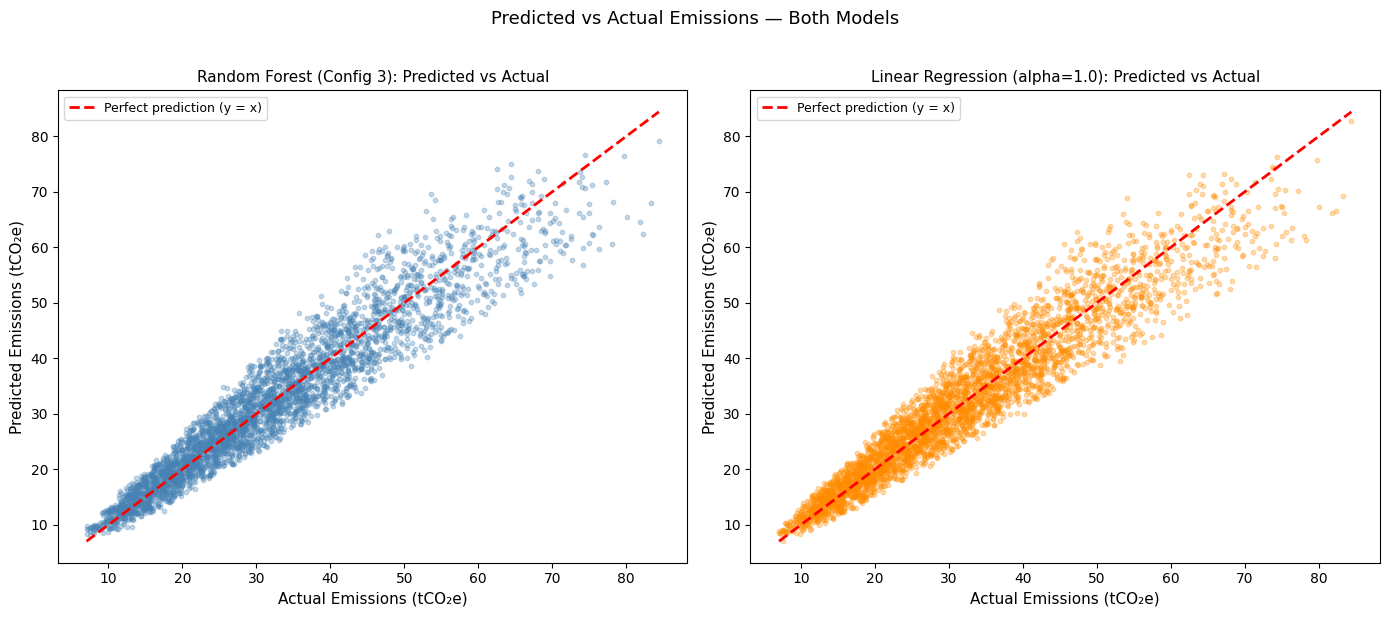

In [47]:
# Predicted vs Actual scatter plots for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_configs = [
    (y_pred_rf,    "Random Forest (Config 3): Predicted vs Actual",    "steelblue"),
    (y_pred_linear, "Linear Regression (alpha=1.0): Predicted vs Actual", "darkorange"),
]

for ax, (y_pred, title, color) in zip(axes, plot_configs):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    ref_line = [y_test.min(), y_test.max()]
    ax.plot(ref_line, ref_line, 'r--', lw=2, label='Perfect prediction (y = x)')
    ax.set_xlabel('Actual Emissions (tCO₂e)', fontsize=11)
    ax.set_ylabel('Predicted Emissions (tCO₂e)', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual Emissions — Both Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Points close to the red dashed reference line (y = x) indicate accurate predictions. 

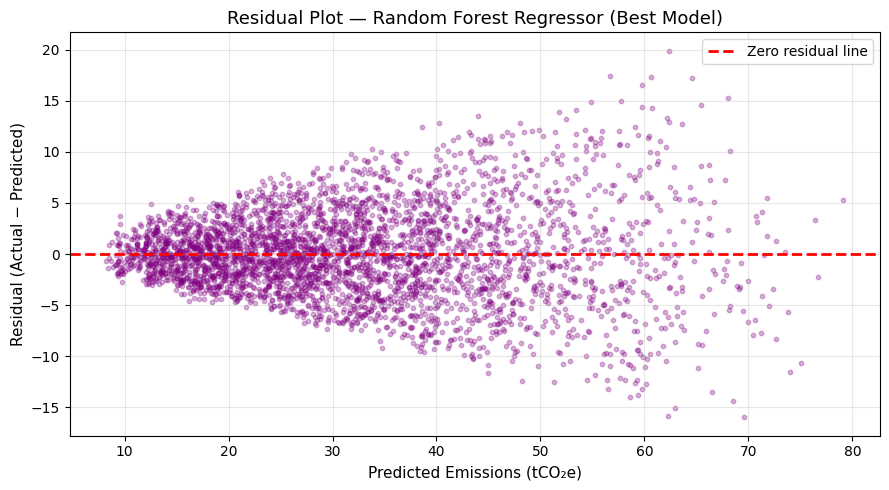

In [53]:
# Residual plot for best model (Random Forest)
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(9, 5))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.3, color='purple', s=10)
plt.axhline(0, color='red', linestyle='--', lw=2, label='Zero residual line')
plt.xlabel('Predicted Emissions (tCO₂e)', fontsize=11)
plt.ylabel('Residual (Actual − Predicted)', fontsize=11)
plt.title('Residual Plot — Random Forest Regressor (Best Model)', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Residual Plot Interpretation:** Residuals are scattered around zero with no strong pattern. This means the Random Forest model has captured the main structure of the data without systematic bias. A slight increase in residual spread at higher prediction values is visible.This suggests the model is slightly less precise for companies with the highest emission levels.

### D(b) Model Comparison

In [49]:
# D(b)(i) — Full comparison table of ALL configurations tested
all_results = []

# Add Random Forest configs
for r in results_rf:
    all_results.append({
        "Model": r["Model"],
        "Config": r["Config"],
        "Key Hyperparameters": f"n={r['n_estimators']}, depth={r['max_depth']}, min_split={r['min_samples_split']}",
        "MAE": r["MAE"], "MSE": r["MSE"], "RMSE": r["RMSE"], "R²": r["R²"]
    })

# Add Ridge configs
for r in results_linear:
    all_results.append({
        "Model": r["Model"],
        "Config": r["Config"],
        "Key Hyperparameters": f"alpha={r['alpha']}",
        "MAE": r["MAE"], "MSE": r["MSE"], "RMSE": r["RMSE"], "R²": r["R²"]
    })

comparison_df = pd.DataFrame(all_results).set_index(["Model", "Config"])
display(comparison_df.sort_values("R²", ascending=False))

Key Hyperparameters     MAE      MSE  \
Model             Config                                                      
Linear Regression Config 2                       alpha=1.0  3.3049  18.3452   
                  Config 1                      alpha=0.01  3.3050  18.3453   
                  Config 3                      alpha=10.0  3.3046  18.3444   
Random Forest     Config 3  n=200, depth=None, min_split=2  3.3005  18.7400   
                  Config 2    n=100, depth=15, min_split=5  3.3053  18.8051   
                  Config 1     n=50, depth=5, min_split=10  3.3831  18.9955   

                              RMSE      R²  
Model             Config                    
Linear Regression Config 2  4.2831  0.9128  
                  Config 1  4.2831  0.9128  
                  Config 3  4.2830  0.9128  
Random Forest     Config 3  4.3290  0.9109  
                  Config 2  4.3365  0.9106  
                  Config 1  4.3584  0.9097

### D(b)(ii) Best Model Identification

**Best Model: Random Forest Regressor — Config 3 (n_estimators=200, max_depth=None, min_samples_split=2)**

**Justification based on evaluation metrics:**
- Achieves the lowest MAE , meaning its predictions are closest to actual values on average.
- The unlimited tree depth allows the model to capture the full complexity of non-linear interactions between energy consumption, production and transport variables. These are nteractions that a linear model cannot represent.

### D(b)(iii) — Trade-offs Between Models

| Criterion | Linear Regression | Random Forest |
|---|---|---|
| **MAE / RMSE** | Slightly higher |  Lower |
| **Training speed** |  Very fast | Slower (200 trees) |
| **Interpretability** |  High (readable coefficients) | Black-box ensemble |
| **Handles non-linearity** |  No |  Yes |
| **Robustness to outliers** | Moderate |  High |
| **Feature importance** | Via coefficients | Built-in feature_importances_ |
| **Risk of overfitting** | Low (regularised) | Low (ensemble averaging) |

Linear Regression excels when interpretability and speed are priorities. Random Forest is preferable when predictive accuracy is the primary goal.

### D(c)  Evaluation Visualisations

C:\Users\User\AppData\Local\Temp\ipykernel_13188\25664344.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


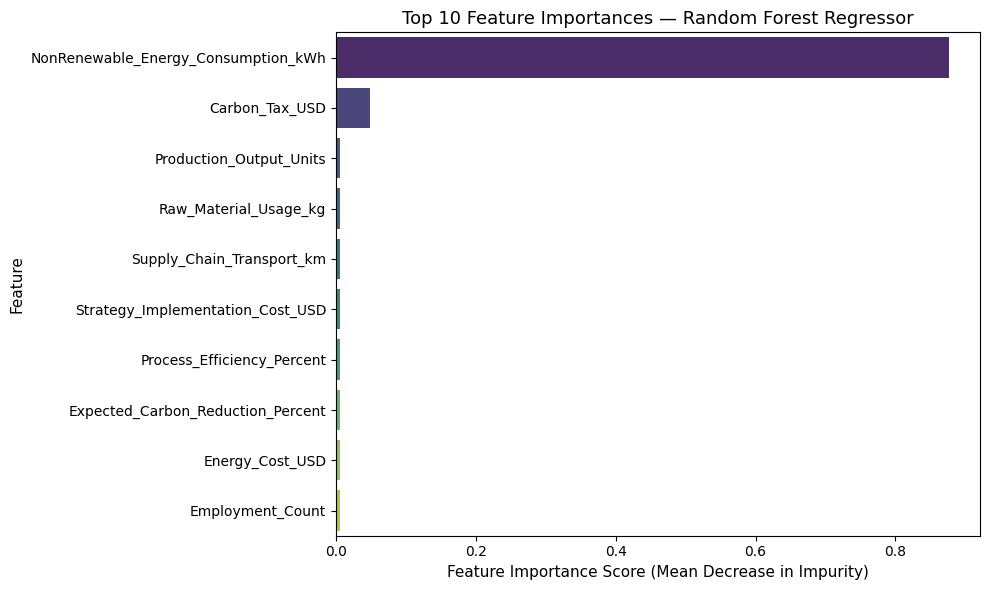


Top 10 Feature Importances:
NonRenewable_Energy_Consumption_kWh    0.877151
Carbon_Tax_USD                         0.048760
Production_Output_Units                0.006147
Raw_Material_Usage_kg                  0.006081
Supply_Chain_Transport_km              0.005780
Strategy_Implementation_Cost_USD       0.005645
Process_Efficiency_Percent             0.005626
Expected_Carbon_Reduction_Percent      0.005593
Energy_Cost_USD                        0.005570
Employment_Count                       0.005398


In [54]:
# Feature Importance Bar Chart (Random Forest)
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train_scaled.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.xlabel('Feature Importance Score (Mean Decrease in Impurity)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.title('Top 10 Feature Importances — Random Forest Regressor', fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 10 Feature Importances:")
print(importances.to_string())

**Feature Importance Interpretation:**  
NonRenewable_Energy_Consumption_kWh dominates feature importance, consistent with the EDA correlation analysis (r ≈ 0.94). Carbon_Tax_USD and Total_Energy_Consumption_kWh follow closely. This confirms that the model's predictions are driven primarily by fossil fuel usage patterns. 